# Visão Clássica — Parte 2: Classificação em Duas Etapas e Detector de Falhas

Continuação da Parte 1, usando o conjunto completo de **181 características**. Aqui o foco é
a **estratégia de classificação**:

1. **Modelo único vs duas etapas** (anomalia vs *No-Anomaly* → tipo).
2. **Detector binário** de falha (a primeira etapa, isolada).
3. **Ajuste do limiar** do detector (trade-off *precision* / *recall*).

## 1. Setup e importações

In [1]:
import json
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from skimage.feature import local_binary_pattern, hog
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, precision_recall_curve
from xgboost import XGBClassifier
from tqdm import tqdm

## 2. Dataset e extração das 181 características

Mesmo extrator e mesmo split (30%, estratificado) da Parte 1, para manter os resultados
comparáveis. O extrator gera as 181 características (base + grade/LBP + skew/kurtose + Hu +
Gabor + HOG).

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "InfraredSolarModules"
DATASET_URL = "https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip"


def garantir_dataset():
    if (DATA_DIR / "module_metadata.json").exists():
        return
    zip_path = BASE_DIR / "2020-02-14_InfraredSolarModules.zip"
    if not zip_path.exists():
        print("Baixando dataset ...")
        urllib.request.urlretrieve(DATASET_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(BASE_DIR)


garantir_dataset()
df = pd.DataFrame.from_dict(json.load(open(DATA_DIR / "module_metadata.json")), orient="index")

GABOR_KERNELS = [cv2.getGaborKernel((9, 9), 2.0, th, 4.0, 0.5, 0, ktype=cv2.CV_32F)
                 for th in np.deg2rad([0, 45, 90, 135])]


def extrair_features(img):
    img = img.astype(np.uint8)
    total = img.size
    f = {}
    f["mean_int"] = float(img.mean())
    f["std_int"] = float(img.std())
    f["max_int"] = float(img.max())
    f["min_int"] = float(img.min())
    f["p90_int"] = float(np.percentile(img, 90))
    otsu_t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, hot = cv2.threshold(img, max(otsu_t, 180), 255, cv2.THRESH_BINARY)
    hot = cv2.morphologyEx(hot, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    f["hot_fraction"] = float(hot.sum() / 255) / total
    contornos, _ = cv2.findContours(hot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = [c for c in contornos if cv2.contourArea(c) >= 2]
    f["num_blobs"] = float(len(blobs))
    if blobs:
        maior = max(blobs, key=cv2.contourArea)
        area = cv2.contourArea(maior)
        x, y, w, h = cv2.boundingRect(maior)
        f["largest_area"] = float(area)
        f["largest_extent"] = float(area / (w * h)) if w * h > 0 else 0.0
        f["largest_aspect"] = float(w / h) if h > 0 else 0.0
    else:
        f["largest_area"] = f["largest_extent"] = f["largest_aspect"] = 0.0
    f["row_cov"] = float((hot.sum(axis=1) > 0).mean())
    f["col_cov"] = float((hot.sum(axis=0) > 0).mean())
    f["dark_fraction"] = float((img < (img.mean() - img.std())).mean())
    f["edge_density"] = float((cv2.Canny(img, 50, 150) > 0).mean())
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    f["grad_mean"] = float(np.sqrt(gx ** 2 + gy ** 2).mean())
    imgf = img.astype(np.float32)
    f["sym_lr"] = float(np.abs(imgf - np.fliplr(imgf)).mean())
    f["sym_tb"] = float(np.abs(imgf - np.flipud(imgf)).mean())
    hist = cv2.calcHist([img], [0], None, [8], [0, 256]).flatten()
    hist = hist / hist.sum()
    for i, hv in enumerate(hist):
        f[f"hist{i}"] = float(hv)
    f["skew_int"] = float(skew(imgf.ravel())) if img.std() > 0 else 0.0
    f["kurt_int"] = float(kurtosis(imgf.ravel())) if img.std() > 0 else 0.0
    hu = np.zeros(7)
    if blobs:
        mk = np.zeros_like(img)
        cv2.drawContours(mk, [maior], -1, 255, -1)
        huv = cv2.HuMoments(cv2.moments(mk)).flatten()
        hu = np.array([-np.sign(v) * np.log10(abs(v) + 1e-30) for v in huv])
    for i in range(7):
        f[f"hu_{i}"] = float(hu[i])
    hh, ww = img.shape
    hs, ws = hh // 3, ww // 3
    for i in range(3):
        for j in range(3):
            y0, y1 = i * hs, (hh if i == 2 else (i + 1) * hs)
            x0, x1 = j * ws, (ww if j == 2 else (j + 1) * ws)
            f[f"grid_{i}{j}"] = float(img[y0:y1, x0:x1].mean())
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    lh, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    for k, v in enumerate(lh):
        f[f"lbp_{k}"] = float(v)
    for i, kern in enumerate(GABOR_KERNELS):
        resp = cv2.filter2D(imgf, cv2.CV_32F, kern)
        f[f"gabor{i}_mean"] = float(resp.mean())
        f[f"gabor{i}_std"] = float(resp.std())
    for k, v in enumerate(hog(imgf, orientations=8, pixels_per_cell=(8, 8),
                              cells_per_block=(1, 1), feature_vector=True, channel_axis=None)):
        f[f"hog_{k}"] = float(v)
    return f


registros, y = [], []
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    img = cv2.imread(str(DATA_DIR / row["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    registros.append(extrair_features(img))
    y.append(row["anomaly_class"])
y = np.array(y)
FEAT_NAMES = list(registros[0].keys())
X = np.array([[r[k] for k in FEAT_NAMES] for r in registros])
print(f"Matriz de características: {X.shape}")

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=42, stratify=y)
Xtr, Xte = X[idx_tr], X[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]
# Rótulos binários e máscara de anomalia (usados nas duas etapas)
y_bin_tr = np.where(y_tr == "No-Anomaly", "No-Anomaly", "Anomalia")
y_bin_te = np.where(y_te == "No-Anomaly", "No-Anomaly", "Anomalia")
mask_anom_tr = y_tr != "No-Anomaly"


def treina_prediz(Xa, ya, Xb, nome):
    """Treina RF / GB / SVM / XGB em (Xa, ya) e prevê Xb."""
    if nome == "RF":
        m = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
        m.fit(Xa, ya)
        return m.predict(Xb)
    if nome == "GB":
        m = HistGradientBoostingClassifier(random_state=42)
        m.fit(Xa, ya, sample_weight=compute_sample_weight("balanced", ya))
        return m.predict(Xb)
    if nome == "SVM":
        m = make_pipeline(StandardScaler(), SVC(class_weight="balanced", random_state=42))
        m.fit(Xa, ya)
        return m.predict(Xb)
    lo = LabelEncoder().fit(ya)
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3, tree_method="hist",
                      random_state=42, n_jobs=-1, eval_metric="mlogloss")
    m.fit(Xa, lo.transform(ya), sample_weight=compute_sample_weight("balanced", ya))
    return lo.inverse_transform(m.predict(Xb))

100%|██████████| 20000/20000 [00:43<00:00, 458.24it/s]


Matriz de características: (20000, 181)


## 3. Modelo único vs classificação em duas etapas

Como a classe `No-Anomaly` é metade da base, testamos **quebrar o problema**:

- **Etapa 1**: classificador binário decide *anomalia* vs *No-Anomaly*.
- **Etapa 2**: outro classificador, treinado **só com anomalias**, decide o tipo.

Comparamos com o **modelo único** (12 classes de uma vez), para os quatro classificadores.
A mesma execução já guarda as métricas do detector binário (etapa 1) para a seção 4.

In [3]:
linhas, detector = [], []
for mn in ["RF", "GB", "SVM", "XGB"]:
    pred_uni = treina_prediz(Xtr, y_tr, Xte, mn)
    pred_bin = treina_prediz(Xtr, y_bin_tr, Xte, mn)
    pred_tipo = treina_prediz(Xtr[mask_anom_tr], y_tr[mask_anom_tr], Xte, mn)
    pred_two = np.where(pred_bin == "Anomalia", pred_tipo, "No-Anomaly")
    linhas.append({"modelo": mn, "abordagem": "único",
                   "acuracia": round(accuracy_score(y_te, pred_uni) * 100, 1),
                   "f1_macro": round(f1_score(y_te, pred_uni, average="macro") * 100, 1)})
    linhas.append({"modelo": mn, "abordagem": "duas etapas",
                   "acuracia": round(accuracy_score(y_te, pred_two) * 100, 1),
                   "f1_macro": round(f1_score(y_te, pred_two, average="macro") * 100, 1)})
    detector.append({"modelo": mn,
                     "acuracia": round(accuracy_score(y_bin_te, pred_bin) * 100, 1),
                     "recall_anomalia": round(recall_score(y_bin_te, pred_bin, pos_label="Anomalia") * 100, 1)})

tab_cmp = pd.DataFrame(linhas).set_index(["modelo", "abordagem"])
print("=== Único vs duas etapas ===")
print(tab_cmp)

=== Único vs duas etapas ===
                    acuracia  f1_macro
modelo abordagem                      
RF     único            67.6      47.7
       duas etapas      69.2      47.5
GB     único            66.8      48.3
       duas etapas      71.0      48.5
SVM    único            64.7      50.4
       duas etapas      71.6      51.6
XGB    único            74.2      53.9
       duas etapas      73.3      52.9


As duas etapas **não** melhoram a classificação fina (o XGBoost único segue melhor). O valor
da divisão está na **primeira etapa**, que sozinha é um detector de falhas robusto.

## 4. Detector binário (anomalia vs No-Anomaly)

Olhando só a etapa 1: "este painel precisa de inspeção?". Mostramos acurácia e *recall* da
classe *Anomalia* (proporção de falhas capturadas) para os quatro modelos.

In [5]:
tab_det = pd.DataFrame(detector).set_index("modelo").sort_values("recall_anomalia", ascending=False)
print(tab_det)

        acuracia  recall_anomalia
modelo                           
XGB         88.4             84.2
SVM         87.7             83.2
GB          86.5             81.9
RF          84.9             79.6


Todos os modelos passam de 80% de *recall*, com o XGBoost à frente. Esse detector pode operar
como um **filtro automático de triagem**, sinalizando módulos suspeitos para inspeção humana —
útil mesmo sem identificar o tipo exato do defeito.

## 5. Ajuste do limiar de decisão (detector XGBoost)

Por padrão o modelo decide *Anomalia* quando a probabilidade passa de 0,5. **Baixar** esse
limiar torna o detector mais sensível: aumenta o *recall* (captura mais falhas) ao custo de
menor *precision* (mais alarmes falsos). Para triagem isso é desejável — um falso negativo
(falha não detectada) é pior que um falso positivo (inspeção à toa).

In [6]:
le_bin = LabelEncoder().fit(y_bin_tr)
xgb_b = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3, tree_method="hist",
                      random_state=42, n_jobs=-1, eval_metric="logloss")
xgb_b.fit(Xtr, le_bin.transform(y_bin_tr), sample_weight=compute_sample_weight("balanced", y_bin_tr))
idx_anom = list(le_bin.classes_).index("Anomalia")
proba = xgb_b.predict_proba(Xte)[:, idx_anom]
ytrue = (y_bin_te == "Anomalia").astype(int)

linhas_lim = []
for t in [0.50, 0.40, 0.30, 0.20, 0.10]:
    pred_t = (proba >= t).astype(int)
    linhas_lim.append({"limiar": t,
                       "recall": round(recall_score(ytrue, pred_t) * 100, 1),
                       "precision": round(precision_score(ytrue, pred_t, zero_division=0) * 100, 1)})
print("=== Trade-off do limiar (detector XGB) ===")
print(pd.DataFrame(linhas_lim).set_index("limiar"))

=== Trade-off do limiar (detector XGB) ===
        recall  precision
limiar                   
0.5       84.2       91.9
0.4       85.8       90.1
0.3       87.8       88.3
0.2       90.2       85.9
0.1       92.8       81.6


### Curva Precision–Recall

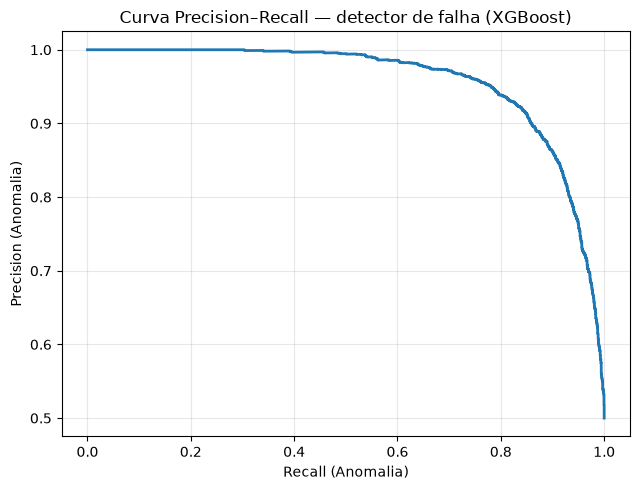

In [7]:
prec, rec, _ = precision_recall_curve(ytrue, proba)
plt.figure(figsize=(6.5, 5))
plt.plot(rec, prec, lw=2)
plt.xlabel("Recall (Anomalia)"); plt.ylabel("Precision (Anomalia)")
plt.title("Curva Precision–Recall — detector de falha (XGBoost)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Reduzindo o limiar, o *recall* sobe progressivamente (capturando quase todas as anomalias) ao
custo de menor *precision*. O operador pode calibrar o ponto de operação para priorizar a
segurança — não deixar passar falhas — aceitando inspecionar alguns painéis sãos a mais.